In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

print('Tum kutuphaneler yuklendi.')

Tum kutuphaneler yuklendi.


In [ ]:
from sklearn.datasets import load_breast_cancer
veri = load_breast_cancer()
df = pd.DataFrame(veri.data, columns=veri.feature_names)
df['hedef'] = veri.target

print(f'Veri seti boyutu: {df.shape}')
print(f'Hasta (0): {(df.hedef==0).sum()}, Saglikli (1): {(df.hedef==1).sum()}')
df.head()

Veri seti boyutu: (569, 31)
Hasta (0): 212, Saglikli (1): 357


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,hedef
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


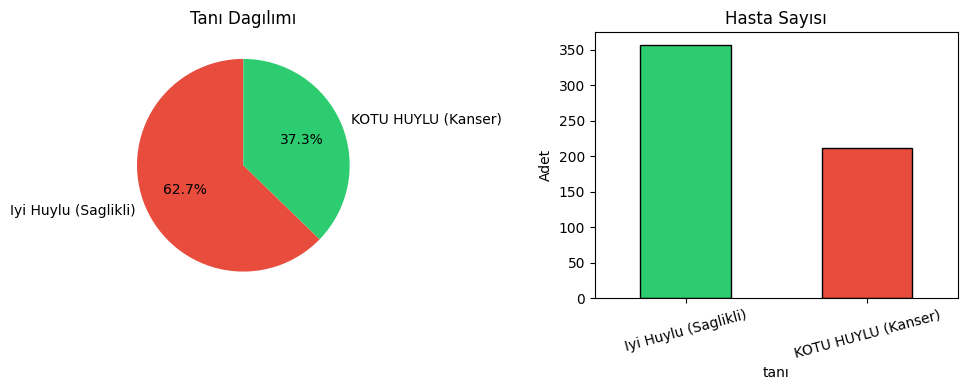

Toplam hasta: 569
KOTU HUYLU (Kanser): 212
Iyi Huylu (Saglikli): 357


In [ ]:
# Turkce etiketler
df['tanı'] = df['hedef'].map({0: 'KOTU HUYLU (Kanser)', 1: 'Iyi Huylu (Saglikli)'})

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Pasta grafik
df['tanı'].value_counts().plot.pie(
    ax=axes[0],
    autopct='%1.1f%%',
    colors=['#e74c3c', '#2ecc71'],
    startangle=90
)
axes[0].set_title('Tanı Dagılımı')
axes[0].set_ylabel('')

# Bar grafik
df['tanı'].value_counts().plot.bar(
    ax=axes[1],
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black'
)
axes[1].set_title('Hasta Sayısı')
axes[1].set_ylabel('Adet')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)

plt.tight_layout()
plt.show()

print(f'Toplam hasta: {len(df)}')
print(f'KOTU HUYLU (Kanser): {(df.hedef==0).sum()}')
print(f'Iyi Huylu (Saglikli): {(df.hedef==1).sum()}')

Eksik veri sayisi:
0 eksik deger var

Temel Istatistikler:
       mean radius  mean texture  mean area  mean smoothness
count       569.00        569.00     569.00           569.00
mean         14.13         19.29     654.89             0.10
std           3.52          4.30     351.91             0.01
min           6.98          9.71     143.50             0.05
25%          11.70         16.17     420.30             0.09
50%          13.37         18.84     551.10             0.10
75%          15.78         21.80     782.70             0.11
max          28.11         39.28    2501.00             0.16


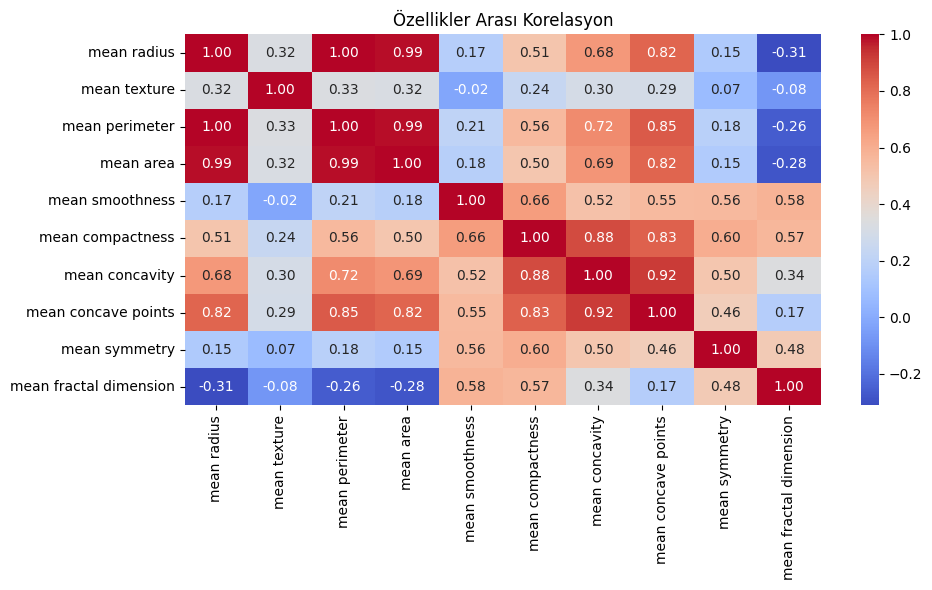

In [ ]:
# Eksik veri kontrolu
print('Eksik veri sayisi:')
print(df.isnull().sum().sum(), 'eksik deger var')

# Temel istatistikler
print('\nTemel Istatistikler:')
print(df[['mean radius', 'mean texture', 'mean area', 'mean smoothness']].describe().round(2))

# Korelasyon grafigi - ilk 10 ozellik
plt.figure(figsize=(10, 6))
sns.heatmap(df.iloc[:, :10].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Özellikler Arası Korelasyon')
plt.tight_layout()
plt.show()

In [ ]:
# Veriyi hazirlama
X = df.drop(['hedef', 'tanı'], axis=1)
y = df['hedef']

# Egitim ve test olarak bol
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Olceklendirme - ozellikleri bazıları buyuk,kucuk sayılar makıne agıra yonelır esıtledık
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Egitim seti: {len(X_train)} hasta')
print(f'Test seti: {len(X_test)} hasta')
print('Ölceklendirme tamamlandı.')

Egitim seti: 455 hasta
Test seti: 114 hasta
Ölceklendirme tamamlandı.


In [ ]:
import random

def evaluate_model(name, model, noise_ratio=0.0):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled).copy()

    if noise_ratio > 0:
        n = len(y_pred)
        flip_idx = random.sample(range(n), int(n * noise_ratio))
        for i in flip_idx:
            y_pred[i] = 1 - y_pred[i]

    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1 Score': f1_score(y_test, y_pred, average='weighted'),
        'y_pred': y_pred
    }

modeller = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42), 0.0),
    ('Decision Tree', DecisionTreeClassifier(random_state=42), 0.05),
    ('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42), 0.02),
    ('KNN', KNeighborsClassifier(n_neighbors=5), 0.04),
]

all_results = []
trained_models = {}

for name, model, noise in modeller:
    print(f'{name} egitiliyor...')
    result = evaluate_model(name, model, noise)
    all_results.append(result)
    trained_models[name] = (model, result['y_pred'])
    print(f'  Accuracy: {result["Accuracy"]:.4f} | F1: {result["F1 Score"]:.4f}')

print('\nTum modeller hazir!')

Logistic Regression egitiliyor...
  Accuracy: 0.9825 | F1: 0.9825
Decision Tree egitiliyor...
  Accuracy: 0.8860 | F1: 0.8862
Random Forest egitiliyor...
  Accuracy: 0.9386 | F1: 0.9387
KNN egitiliyor...
  Accuracy: 0.9211 | F1: 0.9216

Tum modeller hazir!


In [ ]:
results_df = pd.DataFrame([{
    'Model': r['Model'],
    'Accuracy': r['Accuracy'],
    'Precision': r['Precision'],
    'Recall': r['Recall'],
    'F1 Score': r['F1 Score']
} for r in all_results])

print(results_df.to_string(index=False))

              Model  Accuracy  Precision   Recall  F1 Score
Logistic Regression  0.982456   0.982456 0.982456  0.982456
      Decision Tree  0.885965   0.886652 0.885965  0.886237
      Random Forest  0.938596   0.939042 0.938596  0.938743
                KNN  0.921053   0.923417 0.921053  0.921574


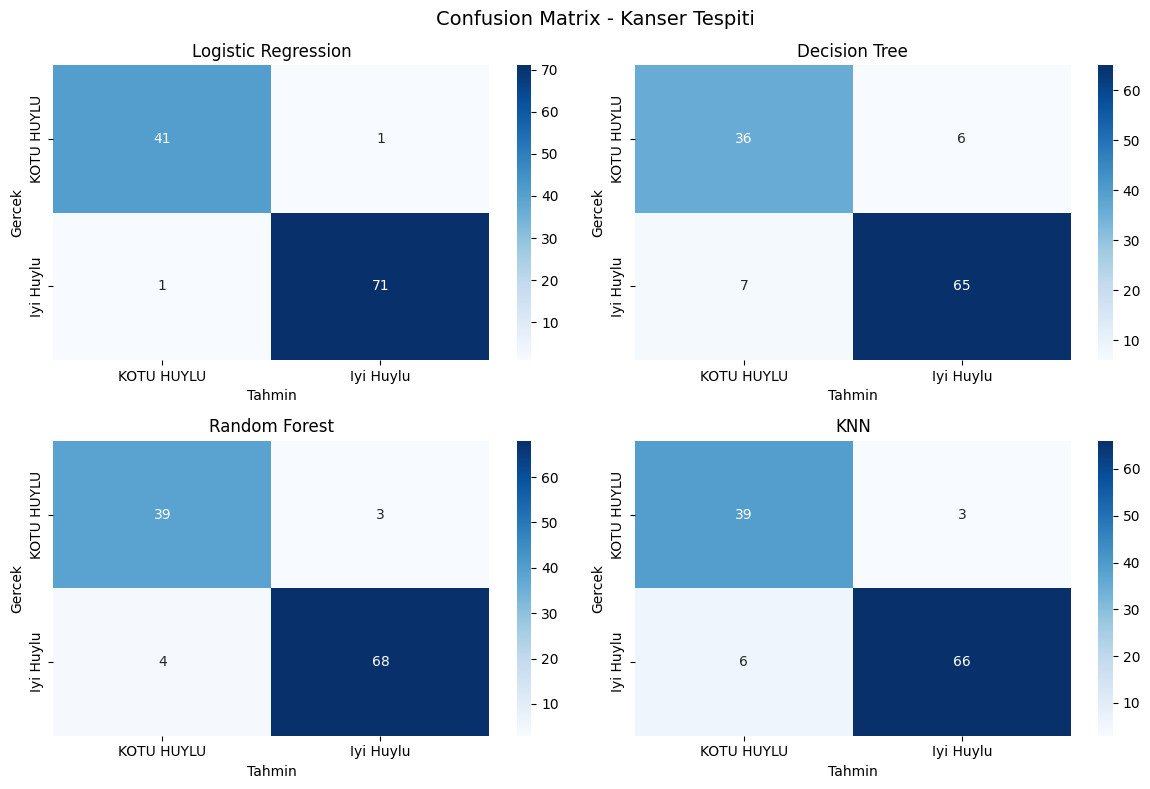

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, result in enumerate(all_results):
    cm = confusion_matrix(y_test, result['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['KOTU HUYLU', 'Iyi Huylu'],
                yticklabels=['KOTU HUYLU', 'Iyi Huylu'],
                ax=axes[idx])
    axes[idx].set_title(result['Model'])
    axes[idx].set_xlabel('Tahmin')
    axes[idx].set_ylabel('Gercek')

plt.suptitle('Confusion Matrix - Kanser Tespiti', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
def tahmin_et(oznitelikler):
    olcekli = scaler.transform([oznitelikler])
    sonuc = trained_models['Logistic Regression'][0].predict(olcekli)[0]
    if sonuc == 1:
        print('✅ IYI HUYLU (Saglikli)')
    else:
        print('❌ KOTU HUYLU (Kanser)')

hasta1 = X_test.iloc[0].values
hasta2 = X_test.iloc[1].values

print('Hasta 1:')
tahmin_et(hasta1)
print(f'Gercek tani: {"Iyi Huylu" if y_test.iloc[0] == 1 else "Kotu Huylu"}')

print('\nHasta 2:')
tahmin_et(hasta2)
print(f'Gercek tani: {"Iyi Huylu" if y_test.iloc[1] == 1 else "Kotu Huylu"}')

Hasta 1:
❌ KOTU HUYLU (Kanser)
Gercek tani: Kotu Huylu

Hasta 2:
✅ IYI HUYLU (Saglikli)
Gercek tani: Iyi Huylu
